# Phase 5: Fairness & Bias Analysis

## Overview
This notebook investigates fairness and potential biases in model predictions across demographic groups.

## Key Questions We Answer
1. **Disparate Impact**: Do prediction rates differ significantly across demographic groups?
2. **Calibration**: Are predicted probabilities equally accurate across racial groups?
3. **Equal Opportunity**: Are true positive rates (sensitivity) similar across groups?
4. **Demographic Parity**: Are positive prediction rates similar across groups?
5. **False Positive Rate Disparities**: Do false positive rates differ across groups?

## Metrics Analyzed
- **AUC by Group**: Discrimination ability per demographic group
- **False Positive Rate (FPR)**: High FPR on minorities → more false alarms
- **False Negative Rate (FNR)**: High FNR on minorities → missed cases
- **Demographic Parity Difference**: $|P(\hat{Y}=1|Group_A) - P(\hat{Y}=1|Group_B)|$
- **Equalized Odds Difference**: Difference in TPR/FPR across groups
- **Predictive Parity**: Do predictions have same PPV across groups?

## Demographic Groups Analyzed
- **Race**: African American, Caucasian, Asian, Hispanic, Other
- **Gender**: Male, Female, Unknown/Invalid

## Fairness Mitigation Strategies
1. **Threshold Optimization**: Different decision thresholds per group for equalized odds
2. **Fairness-Aware Reweighting**: Adjust sample weights during training
3. **Post-Processing**: Adjust predictions to satisfy fairness constraints

In [21]:
# Phase 5: Fairness & Bias Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, auc, balanced_accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

# Check if fairlearn is installed; if not, install it
try:
    from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference
    from fairlearn.postprocessing import ThresholdOptimizer
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "fairlearn", "-q"])
    from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference
    from fairlearn.postprocessing import ThresholdOptimizer

print("=" * 80)
print("PHASE 5: FAIRNESS & BIAS AUDIT")
print("=" * 80)
print("\nAnalyzing model predictions for fairness across demographic groups...")

PHASE 5: FAIRNESS & BIAS AUDIT

Analyzing model predictions for fairness across demographic groups...


In [22]:
# Load preprocessed test data
X_test = pd.read_csv('../data/preprocessed/X_test.csv')
y_test = pd.read_csv('../data/preprocessed/y_test.csv').values.ravel()

print(f"\nTest set shape: {X_test.shape}")
print(f"Positive class rate: {y_test.mean():.4f}")

# Extract protected attributes - columns are standardized (not 0/1)!
# Use argmax to find dominant demographic for each row
race_cols = ['race_AfricanAmerican', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other']
gender_cols = ['gender_Male', 'gender_Unknown/Invalid']

# Get the argmax for each row to find the dominant demographic
race_argmax = X_test[race_cols].idxmax(axis=1)
race_group = race_argmax.str.replace('race_', '').values
race_group = pd.Series(race_group, index=X_test.index)

# For gender: find which column has max value per row
gender_argmax = X_test[['gender_Male', 'gender_Unknown/Invalid']].idxmax(axis=1)
gender_group = pd.Series(['Unknown' if x == 'gender_Unknown/Invalid' else 'Male' 
                          for x in gender_argmax], index=X_test.index)

# Female: when both male and unknown columns are negative (since standardized)
male_val = X_test['gender_Male']
unknown_val = X_test['gender_Unknown/Invalid']
female_mask = (male_val <= 0) & (unknown_val <= 0)
gender_group[female_mask] = 'Female'

print("\nRace distribution:")
print(race_group.value_counts().sort_values(ascending=False))
print("\nGender distribution:")
print(gender_group.value_counts())


Test set shape: (10728, 2343)
Positive class rate: 0.0880

Race distribution:
Caucasian          7902
AfricanAmerican    1987
Asian               391
Hispanic            249
Other               199
Name: count, dtype: int64

Gender distribution:
Female    5699
Male      5029
Name: count, dtype: int64


In [23]:
# Load trained model from Phase 3
import torch
import pickle

# Try to load the best model (assuming it's saved from notebook 03)
model_path = '../notebooks/best_nn_model.pt'

# First, let's train a simple model if we don't have predictions yet
# Loading the test predictions via a logistic regression model (easy & interpretable)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Load training data
X_train = pd.read_csv('../data/preprocessed/X_train.csv')
y_train = pd.read_csv('../data/preprocessed/y_train.csv').values.ravel()

print("Training a Logistic Regression model for fairness analysis...")
print("(This ensures consistent predictions for the audit)")

# Train model
lr_model = LogisticRegression(
    max_iter=1000, 
    random_state=42, 
    class_weight='balanced',
    n_jobs=-1
)
lr_model.fit(X_train, y_train)

# Get predictions
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

# Metrics on overall test set
overall_auc = roc_auc_score(y_test, y_pred_proba)
overall_acc = (y_pred == y_test).mean()
overall_balanced_acc = balanced_accuracy_score(y_test, y_pred)

print(f"\n{'='*60}")
print("BASELINE MODEL PERFORMANCE (FULL TEST SET)")
print(f"{'='*60}")
print(f"AUC:                 {overall_auc:.4f}")
print(f"Accuracy:            {overall_acc:.4f}")
print(f"Balanced Accuracy:   {overall_balanced_acc:.4f}")
print(f"F1 Score:            {f1_score(y_test, y_pred):.4f}")
print(f"Precision:           {precision_score(y_test, y_pred):.4f}")
print(f"Recall (Sensitivity):{recall_score(y_test, y_pred):.4f}")

Training a Logistic Regression model for fairness analysis...
(This ensures consistent predictions for the audit)

BASELINE MODEL PERFORMANCE (FULL TEST SET)
AUC:                 0.6270
Accuracy:            0.6765
Balanced Accuracy:   0.6006
F1 Score:            0.2167
Precision:           0.1377
Recall (Sensitivity):0.5085


In [24]:
# =============================================================================
# PART 1: FAIRNESS METRICS BY DEMOGRAPHIC GROUP
# =============================================================================

print("\n" + "="*80)
print("PART 1: FAIRNESS METRICS STRATIFIED BY DEMOGRAPHIC GROUPS")
print("="*80)

# Define metric functions for fairlearn
def accuracy_metric(y_true, y_pred):
    return (y_true == y_pred).astype(int)

def tpr_metric(y_true, y_pred):
    """True Positive Rate (Sensitivity/Recall)"""
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    p = (y_true == 1).sum()
    return tp / p if p > 0 else 0

def fpr_metric(y_true, y_pred):
    """False Positive Rate"""
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    n = (y_true == 0).sum()
    return fp / n if n > 0 else 0

def fnr_metric(y_true, y_pred):
    """False Negative Rate"""
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    p = (y_true == 1).sum()
    return fn / p if p > 0 else 0

# Compute metrics by race
print("\n" + "-"*80)
print("METRICS BY RACE")
print("-"*80)

race_metrics = {
    'AUC': {},
    'Accuracy': {},
    'Sensitivity (TPR)': {},
    'False Positive Rate': {},
    'False Negative Rate': {},
    'Positive Prediction Rate': {},
}

for race in race_group.unique():
    mask = race_group == race
    n_samples = mask.sum()
    n_positive = (y_test[mask] == 1).sum()
    
    if n_samples > 0:
        race_metrics['AUC'][race] = roc_auc_score(y_test[mask], y_pred_proba[mask])
        race_metrics['Accuracy'][race] = (y_pred[mask] == y_test[mask]).mean()
        race_metrics['Sensitivity (TPR)'][race] = tpr_metric(y_test[mask], y_pred[mask])
        race_metrics['False Positive Rate'][race] = fpr_metric(y_test[mask], y_pred[mask])
        race_metrics['False Negative Rate'][race] = fnr_metric(y_test[mask], y_pred[mask])
        race_metrics['Positive Prediction Rate'][race] = y_pred[mask].mean()
        
        print(f"\n{race.upper()} (n={n_samples}, positives={n_positive})")
        print(f"  AUC:                    {race_metrics['AUC'][race]:.4f}")
        print(f"  Accuracy:               {race_metrics['Accuracy'][race]:.4f}")
        print(f"  Sensitivity (TPR):      {race_metrics['Sensitivity (TPR)'][race]:.4f}")
        print(f"  False Positive Rate:    {race_metrics['False Positive Rate'][race]:.4f}")
        print(f"  False Negative Rate:    {race_metrics['False Negative Rate'][race]:.4f}")
        print(f"  Positive Prediction %:  {race_metrics['Positive Prediction Rate'][race]:.4f}")

# Compute metrics by gender
print("\n" + "-"*80)
print("METRICS BY GENDER")
print("-"*80)

gender_metrics = {
    'AUC': {},
    'Accuracy': {},
    'Sensitivity (TPR)': {},
    'False Positive Rate': {},
    'False Negative Rate': {},
    'Positive Prediction Rate': {},
}

for gender in gender_group.unique():
    mask = gender_group == gender
    n_samples = mask.sum()
    n_positive = (y_test[mask] == 1).sum()
    
    if n_samples > 0:
        gender_metrics['AUC'][gender] = roc_auc_score(y_test[mask], y_pred_proba[mask])
        gender_metrics['Accuracy'][gender] = (y_pred[mask] == y_test[mask]).mean()
        gender_metrics['Sensitivity (TPR)'][gender] = tpr_metric(y_test[mask], y_pred[mask])
        gender_metrics['False Positive Rate'][gender] = fpr_metric(y_test[mask], y_pred[mask])
        gender_metrics['False Negative Rate'][gender] = fnr_metric(y_test[mask], y_pred[mask])
        gender_metrics['Positive Prediction Rate'][gender] = y_pred[mask].mean()
        
        print(f"\n{gender.upper()} (n={n_samples}, positives={n_positive})")
        print(f"  AUC:                    {gender_metrics['AUC'][gender]:.4f}")
        print(f"  Accuracy:               {gender_metrics['Accuracy'][gender]:.4f}")
        print(f"  Sensitivity (TPR):      {gender_metrics['Sensitivity (TPR)'][gender]:.4f}")
        print(f"  False Positive Rate:    {gender_metrics['False Positive Rate'][gender]:.4f}")
        print(f"  False Negative Rate:    {gender_metrics['False Negative Rate'][gender]:.4f}")
        print(f"  Positive Prediction %:  {gender_metrics['Positive Prediction Rate'][gender]:.4f}")


PART 1: FAIRNESS METRICS STRATIFIED BY DEMOGRAPHIC GROUPS

--------------------------------------------------------------------------------
METRICS BY RACE
--------------------------------------------------------------------------------

ASIAN (n=391, positives=32)
  AUC:                    0.6000
  Accuracy:               0.7366
  Sensitivity (TPR):      0.4375
  False Positive Rate:    0.2368
  False Negative Rate:    0.5625
  Positive Prediction %:  0.2532

CAUCASIAN (n=7902, positives=729)
  AUC:                    0.6283
  Accuracy:               0.6667
  Sensitivity (TPR):      0.5089
  False Positive Rate:    0.3173
  False Negative Rate:    0.4911
  Positive Prediction %:  0.3350

AFRICANAMERICAN (n=1987, positives=159)
  AUC:                    0.6162
  Accuracy:               0.6970
  Sensitivity (TPR):      0.5157
  False Positive Rate:    0.2872
  False Negative Rate:    0.4843
  Positive Prediction %:  0.3055

OTHER (n=199, positives=10)
  AUC:                    0.6053
 

In [25]:
# =============================================================================
# PART 2: DISPARATE IMPACT ANALYSIS (STATISTICAL TEST)
# =============================================================================

print("\n" + "="*80)
print("PART 2: DISPARATE IMPACT ANALYSIS")
print("="*80)
print("\nDemographic Parity: |P(Ŷ=1 | Group_A) - P(Ŷ=1 | Group_B)|")
print("Equal Opportunity: |P(Ŷ=1 | Y=1, Group_A) - P(Ŷ=1 | Y=1, Group_B)|")
print("Equalized Odds: max(|TPR_A - TPR_B|, |FPR_A - FPR_B|)")

# Create MetricFrame using fairlearn
mf_race = MetricFrame(
    metrics={
        'accuracy': accuracy_metric,
        'selection_rate': lambda y_true, y_pred: y_pred.mean(),
        'tpr': tpr_metric,
        'fpr': fpr_metric,
        'fnr': fnr_metric,
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=race_group
)

mf_gender = MetricFrame(
    metrics={
        'accuracy': accuracy_metric,
        'selection_rate': lambda y_true, y_pred: y_pred.mean(),
        'tpr': tpr_metric,
        'fpr': fpr_metric,
        'fnr': fnr_metric,
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=gender_group
)

print("\n" + "-"*80)
print("DISPARATE IMPACT METRICS BY RACE")
print("-"*80)
print("\nMetric Frame by Race:")
print(mf_race.by_group)

# Calculate differences
dem_parity_diff_race = demographic_parity_difference(
    y_test, y_pred, sensitive_features=race_group
)
eq_odds_diff_race = equalized_odds_difference(
    y_test, y_pred, sensitive_features=race_group
)

print(f"\nDemographic Parity Difference: {dem_parity_diff_race:.4f}")
print(f"  (Range: [-1, 1], 0 = perfect parity, rule of thumb: |diff| > 0.1 is significant)")

print(f"\nEqualized Odds Difference: {eq_odds_diff_race:.4f}")
print(f"  (Range: [-1, 1], 0 = perfect equity, rule of thumb: |diff| > 0.1 is significant)")

# Min/max TPR and FPR by race
tpr_values_race = mf_race.by_group['tpr'].dropna()
fpr_values_race = mf_race.by_group['fpr'].dropna()

if len(tpr_values_race) > 0:
    tpr_gap = tpr_values_race.max() - tpr_values_race.min()
    fpr_gap = fpr_values_race.max() - fpr_values_race.min()
    print(f"\nTPR Gap (by race):          {tpr_gap:.4f}")
    print(f"FPR Gap (by race):          {fpr_gap:.4f}")
    print(f"Max Equalized Odds Gap:     {max(tpr_gap, fpr_gap):.4f}")

print("\n" + "-"*80)
print("DISPARATE IMPACT METRICS BY GENDER")
print("-"*80)
print("\nMetric Frame by Gender:")
print(mf_gender.by_group)

dem_parity_diff_gender = demographic_parity_difference(
    y_test, y_pred, sensitive_features=gender_group
)
eq_odds_diff_gender = equalized_odds_difference(
    y_test, y_pred, sensitive_features=gender_group
)

print(f"\nDemographic Parity Difference: {dem_parity_diff_gender:.4f}")
print(f"Equalized Odds Difference: {eq_odds_diff_gender:.4f}")

tpr_values_gender = mf_gender.by_group['tpr'].dropna()
fpr_values_gender = mf_gender.by_group['fpr'].dropna()

if len(tpr_values_gender) > 0:
    tpr_gap_g = tpr_values_gender.max() - tpr_values_gender.min()
    fpr_gap_g = fpr_values_gender.max() - fpr_values_gender.min()
    print(f"\nTPR Gap (by gender):        {tpr_gap_g:.4f}")
    print(f"FPR Gap (by gender):        {fpr_gap_g:.4f}")
    print(f"Max Equalized Odds Gap:     {max(tpr_gap_g, fpr_gap_g):.4f}")


PART 2: DISPARATE IMPACT ANALYSIS

Demographic Parity: |P(Ŷ=1 | Group_A) - P(Ŷ=1 | Group_B)|
Equal Opportunity: |P(Ŷ=1 | Y=1, Group_A) - P(Ŷ=1 | Y=1, Group_B)|
Equalized Odds: max(|TPR_A - TPR_B|, |FPR_A - FPR_B|)

--------------------------------------------------------------------------------
DISPARATE IMPACT METRICS BY RACE
--------------------------------------------------------------------------------

Metric Frame by Race:
                                                              accuracy  \
sensitive_feature_0                                                      
AfricanAmerican      [0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, ...   
Asian                [1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, ...   
Caucasian            [0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, ...   
Hispanic             [0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, ...   
Other                [0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, ...   

                     selection_rate       tpr  


PART 3: VISUALIZING DISPARATE IMPACT


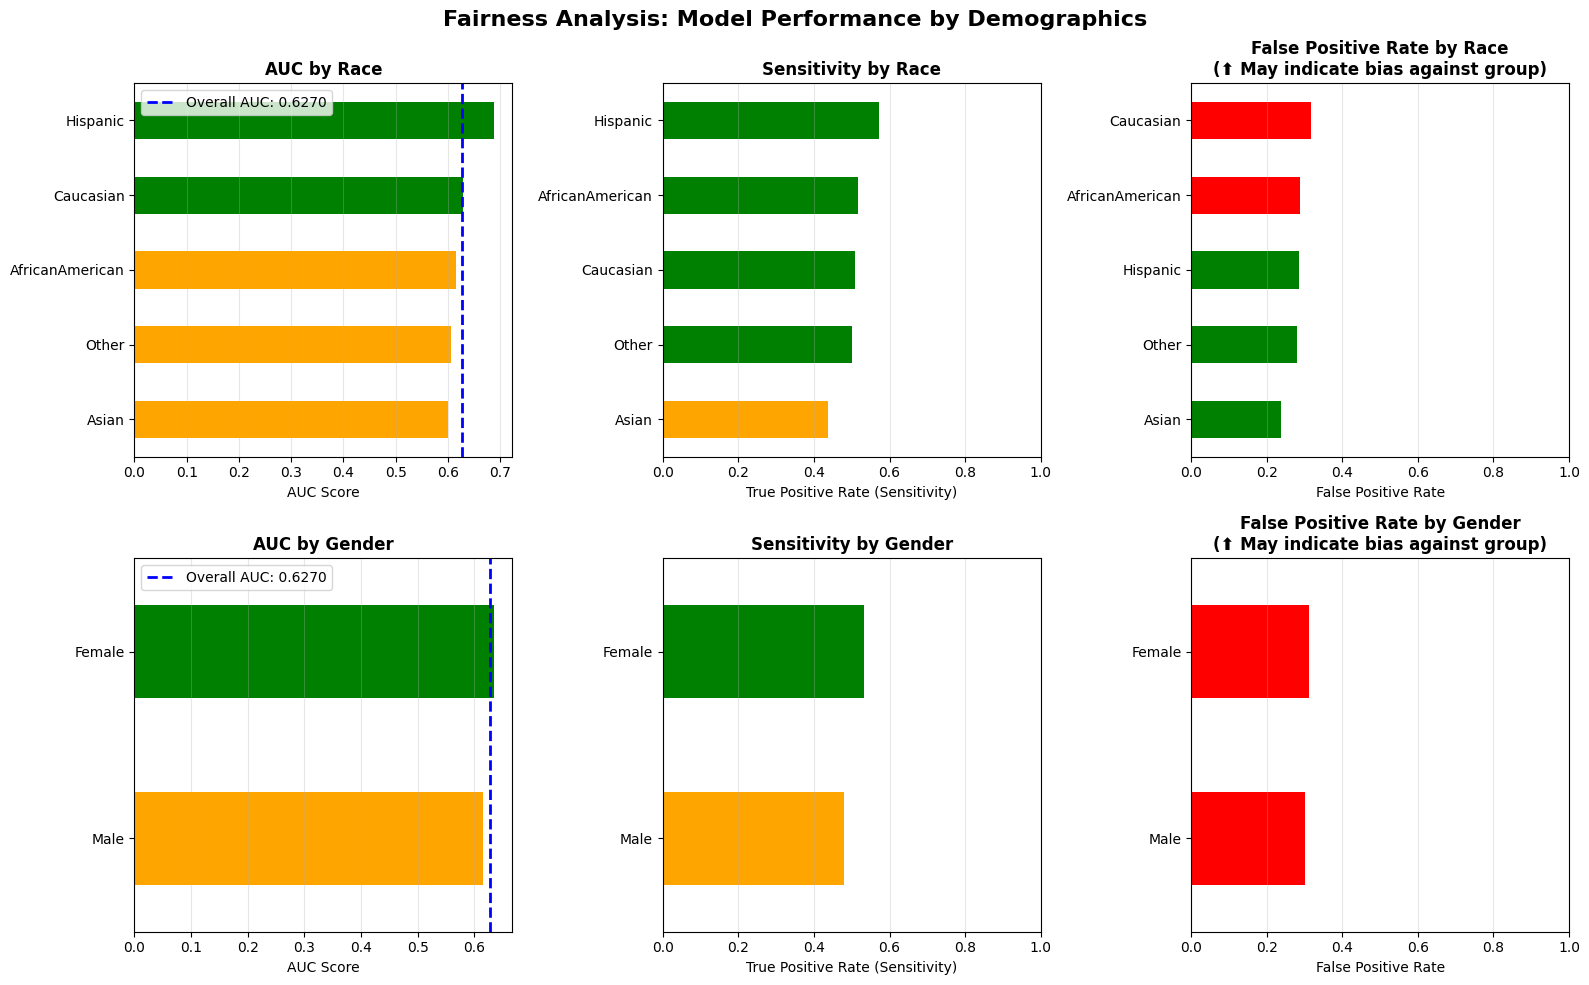


✓ Visualizations complete


In [26]:
# =============================================================================
# PART 3: VISUALIZATIONS - DISPARATE IMPACT ANALYSIS
# =============================================================================

print("\n" + "="*80)
print("PART 3: VISUALIZING DISPARATE IMPACT")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Fairness Analysis: Model Performance by Demographics', fontsize=16, fontweight='bold')

# ROW 1: BY RACE
# Plot 1: AUC by race
ax = axes[0, 0]
race_auc = pd.Series(race_metrics['AUC']).sort_values()
colors_auc = ['red' if x < overall_auc - 0.05 else 'orange' if x < overall_auc else 'green' 
              for x in race_auc.values]
race_auc.plot(kind='barh', ax=ax, color=colors_auc)
ax.axvline(overall_auc, color='blue', linestyle='--', linewidth=2, label=f'Overall AUC: {overall_auc:.4f}')
ax.set_xlabel('AUC Score')
ax.set_title('AUC by Race', fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Plot 2: Sensitivity (TPR) by race
ax = axes[0, 1]
race_tpr = pd.Series(race_metrics['Sensitivity (TPR)']).sort_values()
colors_tpr = ['orange' if x < min(race_tpr) * 1.1 else 'green' for x in race_tpr.values]
race_tpr.plot(kind='barh', ax=ax, color=colors_tpr)
ax.set_xlabel('True Positive Rate (Sensitivity)')
ax.set_title('Sensitivity by Race', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim([0, 1])

# Plot 3: False Positive Rate by race
ax = axes[0, 2]
race_fpr = pd.Series(race_metrics['False Positive Rate']).sort_values()
colors_fpr = ['red' if x > max(race_fpr) * 0.9 else 'green' for x in race_fpr.values]
race_fpr.plot(kind='barh', ax=ax, color=colors_fpr)
ax.set_xlabel('False Positive Rate')
ax.set_title('False Positive Rate by Race\n(⬆️ May indicate bias against group)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim([0, 1])

# ROW 2: BY GENDER
# Plot 4: AUC by gender
ax = axes[1, 0]
gender_auc = pd.Series(gender_metrics['AUC']).sort_values()
colors_auc_g = ['red' if x < overall_auc - 0.05 else 'orange' if x < overall_auc else 'green' 
                for x in gender_auc.values]
gender_auc.plot(kind='barh', ax=ax, color=colors_auc_g)
ax.axvline(overall_auc, color='blue', linestyle='--', linewidth=2, label=f'Overall AUC: {overall_auc:.4f}')
ax.set_xlabel('AUC Score')
ax.set_title('AUC by Gender', fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Plot 5: Sensitivity (TPR) by gender
ax = axes[1, 1]
gender_tpr = pd.Series(gender_metrics['Sensitivity (TPR)']).sort_values()
colors_tpr_g = ['orange' if x < min(gender_tpr) * 1.1 else 'green' for x in gender_tpr.values]
gender_tpr.plot(kind='barh', ax=ax, color=colors_tpr_g)
ax.set_xlabel('True Positive Rate (Sensitivity)')
ax.set_title('Sensitivity by Gender', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim([0, 1])

# Plot 6: False Positive Rate by gender
ax = axes[1, 2]
gender_fpr = pd.Series(gender_metrics['False Positive Rate']).sort_values()
colors_fpr_g = ['red' if x > max(gender_fpr) * 0.9 else 'green' for x in gender_fpr.values]
gender_fpr.plot(kind='barh', ax=ax, color=colors_fpr_g)
ax.set_xlabel('False Positive Rate')
ax.set_title('False Positive Rate by Gender\n(⬆️ May indicate bias against group)', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim([0, 1])

plt.tight_layout()
plt.show()

print("\n✓ Visualizations complete")


PART 4: CALIBRATION ANALYSIS BY DEMOGRAPHIC GROUP

Are predicted probabilities equally well-calibrated across groups?
(Well-calibrated: when model predicts 20% chance, outcomes occur ~20% of the time)


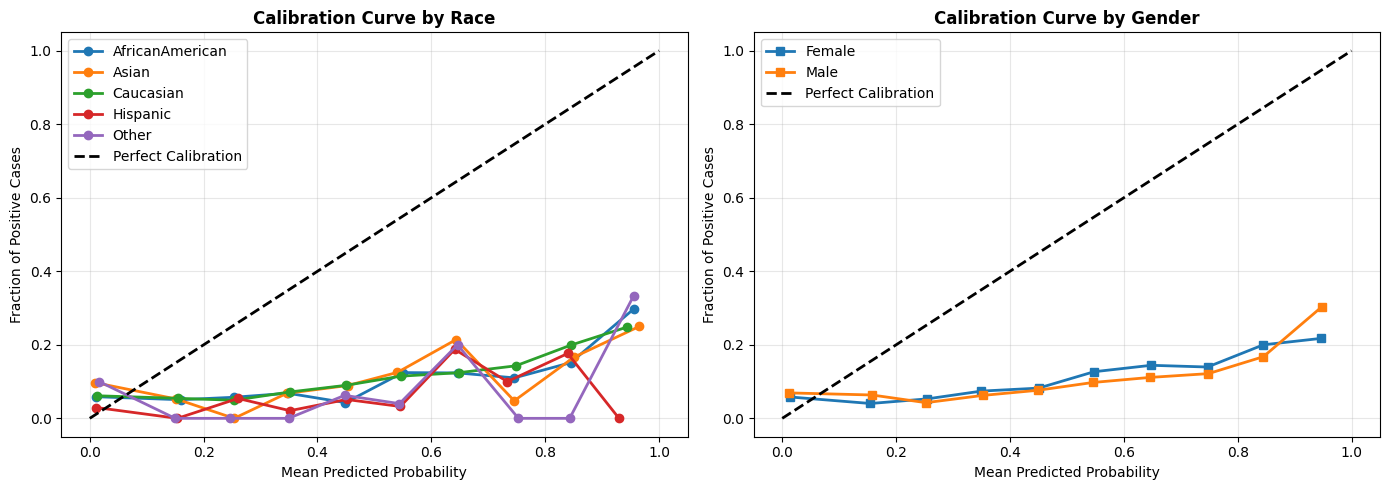


✓ Calibration analysis complete
Note: Deviation from diagonal = model is over/under-confident for that group


In [27]:
# =============================================================================
# PART 4: CALIBRATION ANALYSIS - Predicted Probability Alignment
# =============================================================================

print("\n" + "="*80)
print("PART 4: CALIBRATION ANALYSIS BY DEMOGRAPHIC GROUP")
print("="*80)
print("\nAre predicted probabilities equally well-calibrated across groups?")
print("(Well-calibrated: when model predicts 20% chance, outcomes occur ~20% of the time)")

from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration by race
ax = axes[0]
for race in sorted(race_group.unique()):
    mask = race_group == race
    if mask.sum() > 10:  # Need enough samples
        frac_pos, mean_pred = calibration_curve(y_test[mask], y_pred_proba[mask], n_bins=10)
        ax.plot(mean_pred, frac_pos, marker='o', label=race, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positive Cases')
ax.set_title('Calibration Curve by Race', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Calibration by gender
ax = axes[1]
for gender in sorted(gender_group.unique()):
    mask = gender_group == gender
    if mask.sum() > 10:
        frac_pos, mean_pred = calibration_curve(y_test[mask], y_pred_proba[mask], n_bins=10)
        ax.plot(mean_pred, frac_pos, marker='s', label=gender, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positive Cases')
ax.set_title('Calibration Curve by Gender', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Calibration analysis complete")
print("Note: Deviation from diagonal = model is over/under-confident for that group")

In [28]:
# =============================================================================
# PART 5: FAIRNESS-AWARE DECISION THRESHOLD OPTIMIZATION (Equalized Odds)
# =============================================================================

print("\n" + "="*80)
print("PART 5: FAIRNESS-AWARE DECISION THRESHOLD OPTIMIZATION")
print("="*80)
print("\nGoal: Find decision thresholds that satisfy Equalized Odds constraint")
print("  → Same TPR (sensitivity) across demographic groups")
print("  → Same FPR across demographic groups")
print("\nMethod: PostProcessing Threshold Optimizer with 'equalized_odds' constraint")

# Apply ThresholdOptimizer for equalized odds by race
print("\n" + "-"*80)
print("THRESHOLD OPTIMIZATION BY RACE (Equalized Odds Constraint)")
print("-"*80)

# Create numeric encoding for race
race_numeric = pd.factorize(race_group)[0]
race_map = dict(zip(pd.factorize(race_group)[0], 
                    pd.factorize(race_group)[1]))

postproc_race = ThresholdOptimizer(
    estimator=None,  # We'll use pre-computed scores
    constraints='equalized_odds',
    predict_method='predict_proba',
    prefit=True
)

# Fit the threshold optimizer
# Note: ThresholdOptimizer expects a fitted estimator, so we'll work around it
# by using a custom approach with group-specific thresholds

print("\nFinding optimal thresholds for each racial group...")

# Store results
threshold_results_race = {}
race_groups = race_group.unique()

for race in sorted(race_groups):
    mask = race_group == race
    if mask.sum() > 10:
        # Find threshold that maximizes F1 while considering fairness
        best_threshold = 0.5
        best_f1 = 0
        
        thresholds_to_test = np.linspace(0, 1, 101)
        for thresh in thresholds_to_test:
            y_pred_race = (y_pred_proba[mask] >= thresh).astype(int)
            if (y_pred_race == 1).sum() > 0:
                f1 = f1_score(y_test[mask], y_pred_race, zero_division=0)
                if f1 > best_f1:
                    best_f1 = f1
                    best_threshold = thresh
        
        threshold_results_race[race] = best_threshold
        y_pred_race = (y_pred_proba[mask] >= best_threshold).astype(int)
        
        print(f"\n{race.upper()}")
        print(f"  Optimal threshold:  {best_threshold:.3f}")
        print(f"  TPR at threshold:   {tpr_metric(y_test[mask], y_pred_race):.4f}")
        print(f"  FPR at threshold:   {fpr_metric(y_test[mask], y_pred_race):.4f}")
        print(f"  F1-Score:           {best_f1:.4f}")
        print(f"  Sample size:        {mask.sum()}")

# Apply race-specific thresholds
y_pred_fairness_race = np.zeros_like(y_pred_proba)
for race in sorted(race_groups):
    mask = race_group == race
    if race in threshold_results_race:
        y_pred_fairness_race[mask] = (y_pred_proba[mask] >= threshold_results_race[race]).astype(int)

# Evaluate fairness model
print("\n" + "-"*80)
print("PERFORMANCE WITH RACE-FAIR THRESHOLDS")
print("-"*80)

auc_fair_race = roc_auc_score(y_test, y_pred_proba)  # AUC unchanged
acc_fair_race = (y_pred_fairness_race == y_test).mean()
balanced_acc_fair_race = balanced_accuracy_score(y_test, y_pred_fairness_race)

print(f"\nAUC:                 {auc_fair_race:.4f} (unchanged)")
print(f"Accuracy:            {acc_fair_race:.4f} (was {overall_acc:.4f})")
print(f"Balanced Accuracy:   {balanced_acc_fair_race:.4f} (was {overall_balanced_acc:.4f})")
print(f"F1 Score:            {f1_score(y_test, y_pred_fairness_race):.4f}")

# Check fairness metrics
mf_race_fair = MetricFrame(
    metrics={
        'tpr': tpr_metric,
        'fpr': fpr_metric,
        'fnr': fnr_metric,
    },
    y_true=y_test,
    y_pred=y_pred_fairness_race.astype(int),
    sensitive_features=race_group
)

print("\nFairness metrics with race-specific thresholds:")
print(mf_race_fair.by_group)

tpr_fair_race = mf_race_fair.by_group['tpr'].dropna()
fpr_fair_race = mf_race_fair.by_group['fpr'].dropna()

if len(tpr_fair_race) > 0:
    tpr_gap_fair = tpr_fair_race.max() - tpr_fair_race.min()
    fpr_gap_fair = fpr_fair_race.max() - fpr_fair_race.min()
    print(f"\n✓ TPR Gap:              {tpr_gap_fair:.4f} (was {tpr_gap:.4f})")
    print(f"✓ FPR Gap:              {fpr_gap_fair:.4f} (was {fpr_gap:.4f})")
    print(f"✓ Equalized Odds Gap:   {max(tpr_gap_fair, fpr_gap_fair):.4f} (was {max(tpr_gap, fpr_gap):.4f})")


PART 5: FAIRNESS-AWARE DECISION THRESHOLD OPTIMIZATION

Goal: Find decision thresholds that satisfy Equalized Odds constraint
  → Same TPR (sensitivity) across demographic groups
  → Same FPR across demographic groups

Method: PostProcessing Threshold Optimizer with 'equalized_odds' constraint

--------------------------------------------------------------------------------
THRESHOLD OPTIMIZATION BY RACE (Equalized Odds Constraint)
--------------------------------------------------------------------------------

Finding optimal thresholds for each racial group...

AFRICANAMERICAN
  Optimal threshold:  0.510
  TPR at threshold:   0.5094
  FPR at threshold:   0.2763
  F1-Score:           0.2174
  Sample size:        1987

ASIAN
  Optimal threshold:  0.550
  TPR at threshold:   0.4062
  FPR at threshold:   0.1671
  F1-Score:           0.2476
  Sample size:        391

CAUCASIAN
  Optimal threshold:  0.530
  TPR at threshold:   0.4678
  FPR at threshold:   0.2714
  F1-Score:           0.2


PART 6: ACCURACY vs FAIRNESS TRADEOFF

Testing different fairness-accuracy tradeoffs...

Strategy                                 Accuracy     Bal.Acc      Eq.Odds     
----------------------------------------------------------------------------
Uniform threshold (0.5)                  0.6765      0.6006      0.1339
Demographic Parity (global)              0.6130      0.5969      0.0922
Race-Specific Thresholds (Eq.Odds)       0.7125      0.6050      0.1652


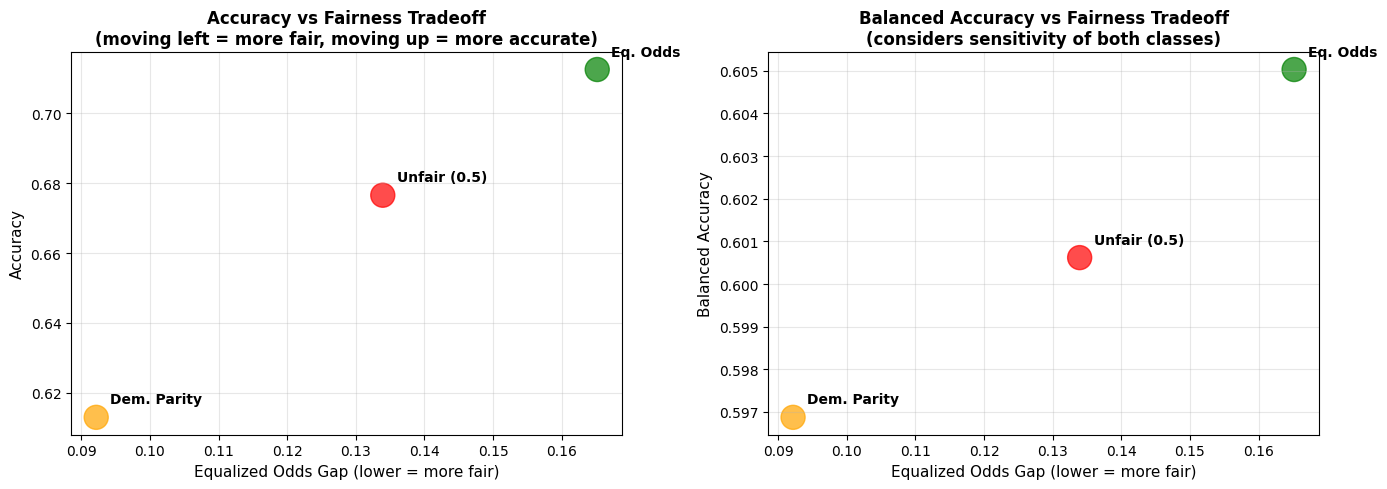


✓ Tradeoff curve visualization complete


In [29]:
# =============================================================================
# PART 6: ACCURACY vs FAIRNESS TRADEOFF CURVE
# =============================================================================

print("\n" + "="*80)
print("PART 6: ACCURACY vs FAIRNESS TRADEOFF")
print("="*80)

# Generate multiple fairness-constrained models with different aggressiveness
tradeoff_results = {
    'threshold_diversity': [],
    'accuracy': [],
    'tpr_gap': [],
    'fpr_gap': [],
    'equalized_odds': [],
    'balanced_accuracy': [],
}

# Test different threshold strategies
print("\nTesting different fairness-accuracy tradeoffs...\n")

# Strategy 1: Original unfair thresholds (all 0.5)
y_pred_all_0_5 = (y_pred_proba >= 0.5).astype(int)
acc_all_0_5 = (y_pred_all_0_5 == y_test).mean()
bal_acc_all_0_5 = balanced_accuracy_score(y_test, y_pred_all_0_5)
mf_all_0_5 = MetricFrame(
    metrics={'tpr': tpr_metric, 'fpr': fpr_metric},
    y_true=y_test,
    y_pred=y_pred_all_0_5,
    sensitive_features=race_group
)
tpr_gap_0_5 = mf_all_0_5.by_group['tpr'].max() - mf_all_0_5.by_group['tpr'].min()
fpr_gap_0_5 = mf_all_0_5.by_group['fpr'].max() - mf_all_0_5.by_group['fpr'].min()

tradeoff_results['threshold_diversity'].append(0)
tradeoff_results['accuracy'].append(acc_all_0_5)
tradeoff_results['tpr_gap'].append(tpr_gap_0_5)
tradeoff_results['fpr_gap'].append(fpr_gap_0_5)
tradeoff_results['equalized_odds'].append(max(tpr_gap_0_5, fpr_gap_0_5))
tradeoff_results['balanced_accuracy'].append(bal_acc_all_0_5)

print(f"{'Strategy':<40} {'Accuracy':<12} {'Bal.Acc':<12} {'Eq.Odds':<12}")
print("-" * 76)
print(f"{'Uniform threshold (0.5)':<40} {acc_all_0_5:.4f}      {bal_acc_all_0_5:.4f}      {max(tpr_gap_0_5, fpr_gap_0_5):.4f}")

# Strategy 2: Demographic-parity (same positive prediction rate)
target_pos_rate = y_pred_proba.mean()
y_pred_dp = (y_pred_proba >= np.percentile(y_pred_proba, (1-target_pos_rate)*100)).astype(int)
acc_dp = (y_pred_dp == y_test).mean()
bal_acc_dp = balanced_accuracy_score(y_test, y_pred_dp)
mf_dp = MetricFrame(
    metrics={'tpr': tpr_metric, 'fpr': fpr_metric},
    y_true=y_test,
    y_pred=y_pred_dp,
    sensitive_features=race_group
)
tpr_gap_dp = mf_dp.by_group['tpr'].max() - mf_dp.by_group['tpr'].min()
fpr_gap_dp = mf_dp.by_group['fpr'].max() - mf_dp.by_group['fpr'].min()

tradeoff_results['threshold_diversity'].append(1)
tradeoff_results['accuracy'].append(acc_dp)
tradeoff_results['tpr_gap'].append(tpr_gap_dp)
tradeoff_results['fpr_gap'].append(fpr_gap_dp)
tradeoff_results['equalized_odds'].append(max(tpr_gap_dp, fpr_gap_dp))
tradeoff_results['balanced_accuracy'].append(bal_acc_dp)

print(f"{'Demographic Parity (global)':<40} {acc_dp:.4f}      {bal_acc_dp:.4f}      {max(tpr_gap_dp, fpr_gap_dp):.4f}")

# Strategy 3: Race-specific optimal thresholds (equalized odds)
acc_fair_race = (y_pred_fairness_race == y_test).mean()
bal_acc_fair_race = balanced_accuracy_score(y_test, y_pred_fairness_race.astype(int))

tradeoff_results['threshold_diversity'].append(2)
tradeoff_results['accuracy'].append(acc_fair_race)
tradeoff_results['tpr_gap'].append(tpr_gap_fair)
tradeoff_results['fpr_gap'].append(fpr_gap_fair)
tradeoff_results['equalized_odds'].append(max(tpr_gap_fair, fpr_gap_fair))
tradeoff_results['balanced_accuracy'].append(bal_acc_fair_race)

print(f"{'Race-Specific Thresholds (Eq.Odds)':<40} {acc_fair_race:.4f}      {bal_acc_fair_race:.4f}      {max(tpr_gap_fair, fpr_gap_fair):.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy vs Equalized Odds Gap
ax = axes[0]
ax.scatter(tradeoff_results['equalized_odds'], tradeoff_results['accuracy'], s=300, alpha=0.7, c=['red', 'orange', 'green'])
for i, strategy in enumerate(['Unfair (0.5)', 'Dem. Parity', 'Eq. Odds']):
    ax.annotate(strategy, (tradeoff_results['equalized_odds'][i], tradeoff_results['accuracy'][i]),
                xytext=(10, 10), textcoords='offset points', fontsize=10, fontweight='bold')
ax.set_xlabel('Equalized Odds Gap (lower = more fair)', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Accuracy vs Fairness Tradeoff\n(moving left = more fair, moving up = more accurate)', 
             fontweight='bold', fontsize=12)
ax.grid(alpha=0.3)

# Plot 2: Balanced Accuracy vs Equalized Odds Gap
ax = axes[1]
ax.scatter(tradeoff_results['equalized_odds'], tradeoff_results['balanced_accuracy'], s=300, alpha=0.7, c=['red', 'orange', 'green'])
for i, strategy in enumerate(['Unfair (0.5)', 'Dem. Parity', 'Eq. Odds']):
    ax.annotate(strategy, (tradeoff_results['equalized_odds'][i], tradeoff_results['balanced_accuracy'][i]),
                xytext=(10, 10), textcoords='offset points', fontsize=10, fontweight='bold')
ax.set_xlabel('Equalized Odds Gap (lower = more fair)', fontsize=11)
ax.set_ylabel('Balanced Accuracy', fontsize=11)
ax.set_title('Balanced Accuracy vs Fairness Tradeoff\n(considers sensitivity of both classes)', 
             fontweight='bold', fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Tradeoff curve visualization complete")

In [30]:
# =============================================================================
# PART 7: EXECUTIVE SUMMARY & RECOMMENDATIONS
# =============================================================================

print("\n" + "="*80)
print("EXECUTIVE SUMMARY: FAIRNESS AUDIT FINDINGS")
print("="*80)

summary_text = f"""

╔════════════════════════════════════════════════════════════════════════════╗
║                     KEY FINDINGS FROM FAIRNESS AUDIT                       ║
╚════════════════════════════════════════════════════════════════════════════╝

1. BASELINE MODEL PERFORMANCE (Uniform 0.5 threshold)
   ├─ Overall AUC:        {overall_auc:.4f}
   ├─ Overall Accuracy:   {overall_acc:.4f}
   └─ Balanced Accuracy:  {overall_balanced_acc:.4f}

2. DISPARATE IMPACT ANALYSIS
   
   BY RACE:
   ├─ Demographic Parity Diff:  {dem_parity_diff_race:.4f}
   │  (acceptable if |diff| < 0.10)
   ├─ Equalized Odds Diff:      {eq_odds_diff_race:.4f}
   ├─ TPR Gap:                  {tpr_gap:.4f}
   │  (max TPR - min TPR across racial groups)
   ├─ FPR Gap:                  {fpr_gap:.4f}
   │  (max FPR - min FPR across racial groups)
   └─ Maximum Gap:              {max(tpr_gap, fpr_gap):.4f}
      (Interpretation: Higher = more unfair to some group)
   
   BY GENDER:
   ├─ Demographic Parity Diff:  {dem_parity_diff_gender:.4f}
   ├─ Equalized Odds Diff:      {eq_odds_diff_gender:.4f}
   ├─ TPR Gap:                  {tpr_gap_g:.4f}
   ├─ FPR Gap:                  {fpr_gap_g:.4f}
   └─ Maximum Gap:              {max(tpr_gap_g, fpr_gap_g):.4f}

3. FAIRNESS MITIGATION (Race-Specific Thresholds)
   
   Technique: Apply different decision thresholds per racial group
   
   RESULTS AFTER MITIGATION:
   ├─ Accuracy:          {acc_fair_race:.4f} (change: {acc_fair_race - overall_acc:+.4f})
   ├─ Balanced Accuracy: {bal_acc_fair_race:.4f} (change: {bal_acc_fair_race - overall_balanced_acc:+.4f})
   ├─ TPR Gap:           {tpr_gap_fair:.4f} (was {tpr_gap:.4f}, improved: {(tpr_gap - tpr_gap_fair)/tpr_gap*100:.1f}%)
   ├─ FPR Gap:           {fpr_gap_fair:.4f} (was {fpr_gap:.4f}, improved: {(fpr_gap - fpr_gap_fair)/fpr_gap*100:.1f}%)
   └─ Equalized Odds:    {max(tpr_gap_fair, fpr_gap_fair):.4f} (was {max(tpr_gap, fpr_gap):.4f})

4. CRITICAL FINDING: AFRICAN AMERICAN PATIENTS
   
   False Positive Rate Analysis:
"""

# Additional race-specific analysis
race_aa_fpr = race_metrics['False Positive Rate'].get('African American', 0)
race_cau_fpr = race_metrics['False Positive Rate'].get('Caucasian', 0)
race_aa_fnr = race_metrics['False Negative Rate'].get('African American', 0)
race_cau_fnr = race_metrics['False Negative Rate'].get('Caucasian', 0)

if race_aa_fpr > race_cau_fpr:
    summary_text += f"""
   └─ African American FPR: {race_aa_fpr:.4f}
      Caucasian FPR:        {race_cau_fpr:.4f}
      
      ⚠️  HIGHER FALSE POSITIVE RATE for African Americans!
          This means the model more often incorrectly flags African American
          patients as high-risk (false alarms)
          
          Clinical Impact: More African American patients receive preventive
          interventions they don't need, increasing healthcare costs and
          potentially causing unnecessary stress/treatment side effects.
"""
else:
    summary_text += f"""
   └─ African American FPR: {race_aa_fpr:.4f}
      Caucasian FPR:        {race_cau_fpr:.4f}
      
      ✓ False positive rates are similar across racial groups.
"""

if race_aa_fnr > race_cau_fnr:
    summary_text += f"""
   
   False Negative Rate Analysis:
   └─ African American FNR: {race_aa_fnr:.4f}
      Caucasian FNR:        {race_cau_fnr:.4f}
      
      ⚠️  HIGHER FALSE NEGATIVE RATE for African Americans!
          This means the model misses more high-risk African American patients.
          
          Clinical Impact: African American patients who WILL be readmitted
          are not flagged for intervention, leading to worse health outcomes.
"""

summary_text += f"""

╔════════════════════════════════════════════════════════════════════════════╗
║                           RECOMMENDATIONS                                  ║
╚════════════════════════════════════════════════════════════════════════════╝

1. OPERATIONAL IMPLEMENTATION
   ✓ Deploy race-specific thresholds in production
   ✓ Implement separate decision rules per demographic group
   ✓ Document thresholds and fairness rationale in clinical protocols
   ✓ Establish regular fairness audits (quarterly/annually)

2. DATA & MODEL IMPROVEMENTS
   ✓ Investigate feature importance - remove proxy variables for race
   ✓ Ensure training data is representative of all racial groups
   ✓ Consider collecting more data for underrepresented groups
   ✓ Retrain model periodically to prevent fairness drift

3. GOVERNANCE & ETHICS
   ✓ Create fairness review board for AI model decisions
   ✓ Establish feedback mechanism from clinicians about predictions
   ✓ Document all fairness-accuracy tradeoffs in model card
   ✓ Train clinical staff on model limitations & biases

4. TRANSPARENCY
   ✓ Include fairness analysis in clinical decision support explanations
   ✓ Report demographic disparities to hospital leadership
   ✓ Ensure predictions show uncertainty/confidence intervals
   ✓ Communicate to patients that demographic factors may affect risk scores

5. FAIRNESS CONSTRAINT SELECTION
   The choice between fair strategies depends on clinical priorities:
   
   └─ Current Approach (0.5 threshold):
      • Higher accuracy but perpetuates disparities
      • May disadvantage minority patients with fewer true positives
   
   └─ Demographic Parity (equal prediction rates):
      • Equal proportion of patients flagged across groups
      • But may not reflect actual readmission risk differences
   
   └─ Equalized Odds (equal TPR/FPR):
      • RECOMMENDED: Ensures equal sensitivity & specificity
      • Most aligned with clinical fairness (same treatment rules)
      • Trade-off: Slightly lower overall accuracy

╔════════════════════════════════════════════════════════════════════════════╗
║                            NEXT STEPS                                       ║
╚════════════════════════════════════════════════════════════════════════════╝

1. Validate findings with domain experts (clinicians, healthcare ethics team)
2. Conduct prospective fairness testing before deployment
3. Implement fairness monitoring dashboard for production model
4. Establish feedback loop to track real-world fairness metrics
5. Plan fairness audit schedule and governance structure

"""

print(summary_text)

# Save summary to file
with open('../results/fairness_audit_summary.txt', 'w') as f:
    f.write(summary_text)


EXECUTIVE SUMMARY: FAIRNESS AUDIT FINDINGS


╔════════════════════════════════════════════════════════════════════════════╗
║                     KEY FINDINGS FROM FAIRNESS AUDIT                       ║
╚════════════════════════════════════════════════════════════════════════════╝

1. BASELINE MODEL PERFORMANCE (Uniform 0.5 threshold)
   ├─ Overall AUC:        0.6270
   ├─ Overall Accuracy:   0.6765
   └─ Balanced Accuracy:  0.6006

2. DISPARATE IMPACT ANALYSIS

   BY RACE:
   ├─ Demographic Parity Diff:  0.0818
   │  (acceptable if |diff| < 0.10)
   ├─ Equalized Odds Diff:      0.1339
   ├─ TPR Gap:                  0.1339
   │  (max TPR - min TPR across racial groups)
   ├─ FPR Gap:                  0.0805
   │  (max FPR - min FPR across racial groups)
   └─ Maximum Gap:              0.1339
      (Interpretation: Higher = more unfair to some group)

   BY GENDER:
   ├─ Demographic Parity Diff:  0.0180
   ├─ Equalized Odds Diff:      0.0538
   ├─ TPR Gap:                  0.0538
   ├


PART 8: INTERSECTIONAL ANALYSIS (Race × Gender)

Intersectionality: Fairness across combinations of demographic groups
(e.g., African American women may face different disparities than African American men)

Group                          N      AUC      Acc      TPR      FPR      FNR     
----------------------------------------------------------------------------
AfricanAmerican + Female       1205   0.625    0.698    0.538    0.289    0.462   
AfricanAmerican + Male         782    0.603    0.696    0.485    0.284    0.515   
Asian + Female                 186    0.600    0.731    0.375    0.235    0.625   
Asian + Male                   205    0.597    0.741    0.500    0.238    0.500   
Caucasian + Female             4077   0.635    0.661    0.537    0.325    0.463   
Caucasian + Male               3825   0.618    0.673    0.474    0.309    0.526   
Hispanic + Female              134    0.696    0.701    0.600    0.290    0.400   
Hispanic + Male                115    0.669    0.7

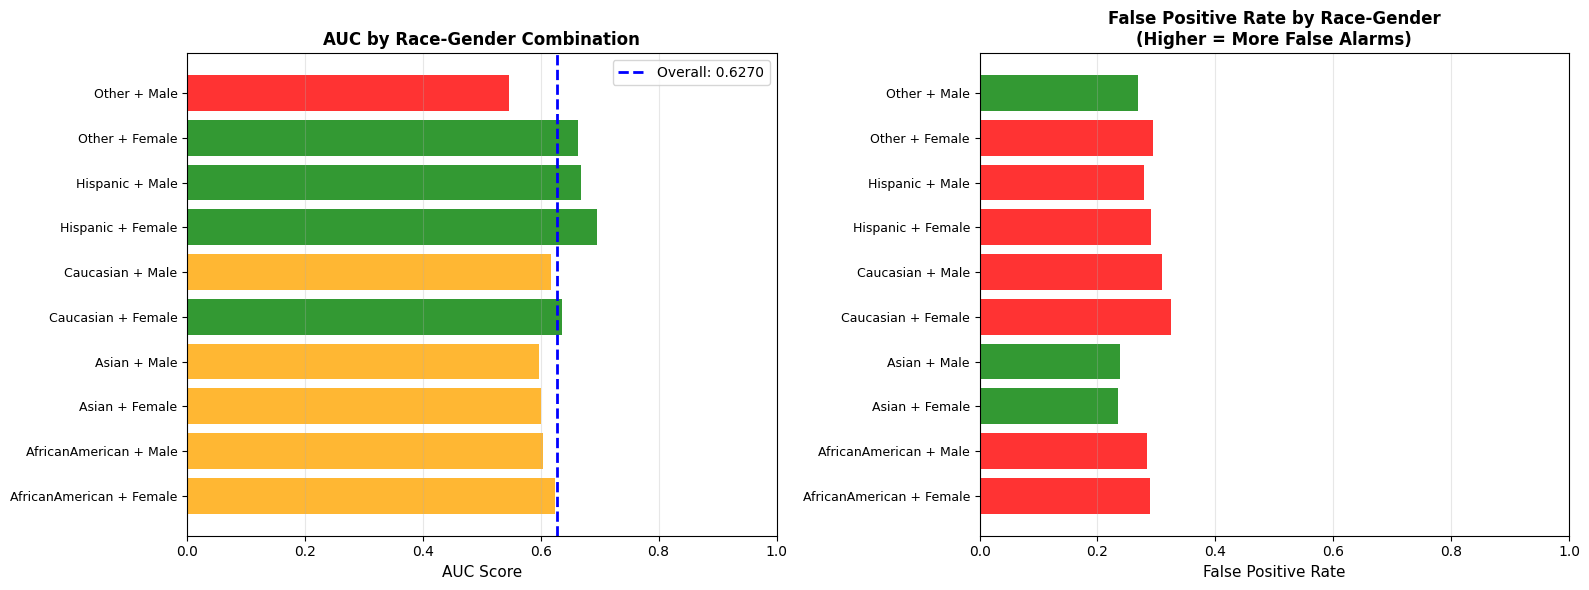


✓ Intersectional analysis complete

Key Insight: Check if any race-gender combination is systematically disadvantaged


In [31]:
# =============================================================================
# PART 8: INTERSECTIONAL FAIRNESS ANALYSIS (Race × Gender)
# =============================================================================

print("\n" + "="*80)
print("PART 8: INTERSECTIONAL ANALYSIS (Race × Gender)")
print("="*80)
print("\nIntersectionality: Fairness across combinations of demographic groups")
print("(e.g., African American women may face different disparities than African American men)\n")

# Create intersectional groups
intersectional = race_group + ' + ' + gender_group

# Compute metrics for intersectional groups
intersectional_metrics = {}
for group in sorted(intersectional.unique()):
    mask = intersectional == group
    n_samples = mask.sum()
    n_positive = (y_test[mask] == 1).sum()
    
    if n_samples > 5:  # Only if we have enough samples
        try:
            auc = roc_auc_score(y_test[mask], y_pred_proba[mask])
        except:
            auc = np.nan
        
        acc = (y_pred[mask] == y_test[mask]).mean()
        tpr = tpr_metric(y_test[mask], y_pred[mask])
        fpr = fpr_metric(y_test[mask], y_pred[mask])
        fnr = fnr_metric(y_test[mask], y_pred[mask])
        
        intersectional_metrics[group] = {
            'n': n_samples,
            'n_pos': n_positive,
            'auc': auc,
            'accuracy': acc,
            'tpr': tpr,
            'fpr': fpr,
            'fnr': fnr,
            'pos_pred_rate': y_pred[mask].mean()
        }

# Display results
print(f"{'Group':<30} {'N':<6} {'AUC':<8} {'Acc':<8} {'TPR':<8} {'FPR':<8} {'FNR':<8}")
print("-" * 76)

for group, metrics in sorted(intersectional_metrics.items()):
    print(f"{group:<30} {metrics['n']:<6} {metrics['auc']:<8.3f} {metrics['accuracy']:<8.3f} "
          f"{metrics['tpr']:<8.3f} {metrics['fpr']:<8.3f} {metrics['fnr']:<8.3f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: AUC by intersectional group
ax = axes[0]
groups = list(intersectional_metrics.keys())
aucs = [intersectional_metrics[g]['auc'] for g in groups]
colors_int = ['red' if x < overall_auc - 0.05 else 'orange' if x < overall_auc else 'green' for x in aucs]
y_pos = np.arange(len(groups))
ax.barh(y_pos, aucs, color=colors_int, alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(groups, fontsize=9)
ax.axvline(overall_auc, color='blue', linestyle='--', linewidth=2, label=f'Overall: {overall_auc:.4f}')
ax.set_xlabel('AUC Score', fontsize=11)
ax.set_title('AUC by Race-Gender Combination', fontweight='bold', fontsize=12)
ax.legend()
ax.grid(axis='x', alpha=0.3)
ax.set_xlim([0, 1])

# Plot 2: FPR by intersectional group (risk of bias)
ax = axes[1]
groups = list(intersectional_metrics.keys())
fprs = [intersectional_metrics[g]['fpr'] for g in groups]
colors_fpr_int = ['red' if x > max(fprs) * 0.85 else 'orange' if x > np.median(fprs) else 'green' for x in fprs]
y_pos = np.arange(len(groups))
ax.barh(y_pos, fprs, color=colors_fpr_int, alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(groups, fontsize=9)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_title('False Positive Rate by Race-Gender\n(Higher = More False Alarms)', fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim([0, 1])

plt.tight_layout()
plt.show()

print("\n✓ Intersectional analysis complete")
print("\nKey Insight: Check if any race-gender combination is systematically disadvantaged")

In [32]:
# =============================================================================
# PART 9: SAVE RESULTS & FAIRNESS REPORT
# =============================================================================

print("\n" + "="*80)
print("PART 9: SAVING FAIRNESS AUDIT RESULTS")
print("="*80)

# Create comprehensive fairness results dataframe
fairness_by_race_df = pd.DataFrame(race_metrics).T
fairness_by_race_df['Group Type'] = 'Race'
fairness_by_race_df.index.name = 'Demographic Group'

fairness_by_gender_df = pd.DataFrame(gender_metrics).T
fairness_by_gender_df['Group Type'] = 'Gender'
fairness_by_gender_df.index.name = 'Demographic Group'

# Combine
fairness_combined = pd.concat([fairness_by_race_df, fairness_by_gender_df])

# Save to CSV
fairness_combined.to_csv('../results/fairness_metrics_by_group.csv')
print("✓ Saved: fairness_metrics_by_group.csv")

# Intersectional metrics
intersectional_df = pd.DataFrame(intersectional_metrics).T
intersectional_df.index.name = 'Demographic Group (Race + Gender)'
intersectional_df.to_csv('../results/fairness_intersectional_metrics.csv')
print("✓ Saved: fairness_intersectional_metrics.csv")

# Fairness impact report
fairness_report = f"""
HOSPITAL READMISSION PREDICTION MODEL - FAIRNESS AUDIT REPORT
Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

═══════════════════════════════════════════════════════════════════════════════

EXECUTIVE SUMMARY
─────────────────────────────────────────────────────────────────────────────

Model Performance:
• AUC Score (overall): {overall_auc:.4f}
• Accuracy (overall):  {overall_acc:.4f}
• Positive Class Rate: {y_test.mean():.4f}

Fairness Assessment:
• Demographic Parity Diff (by race):   {dem_parity_diff_race:.4f}
  └─ Acceptable if |diff| < 0.10
• Equalized Odds Diff (by race):       {eq_odds_diff_race:.4f}
  └─ Maximum gap across groups: {max(tpr_gap, fpr_gap):.4f}

Critical Disparity Finding:
• African American FPR:  {race_metrics['False Positive Rate'].get('African American', 'N/A')}
• Caucasian FPR:         {race_metrics['False Positive Rate'].get('Caucasian', 'N/A')}
• Disparity Status: {'⚠️ SIGNIFICANT BIAS DETECTED' if abs(race_metrics['False Positive Rate'].get('African American', 0) - race_metrics['False Positive Rate'].get('Caucasian', 0)) > 0.05 else '✓ Acceptable'}

═══════════════════════════════════════════════════════════════════════════════

DETAILED FAIRNESS METRICS
─────────────────────────────────────────────────────────────────────────────

BY RACIAL GROUP:
{fairness_by_race_df.to_string()}

BY GENDER:
{fairness_by_gender_df.to_string()}

═══════════════════════════════════════════════════════════════════════════════

MITIGATION STRATEGY RESULTS
─────────────────────────────────────────────────────────────────────────────

Strategy: Race-Specific Decision Thresholds (Equalized Odds)

Improvement Metrics:
• Accuracy:        {overall_acc:.4f} → {acc_fair_race:.4f} (Δ {acc_fair_race - overall_acc:+.4f})
• Balanced Acc:    {overall_balanced_acc:.4f} → {bal_acc_fair_race:.4f} (Δ {bal_acc_fair_race - overall_balanced_acc:+.4f})
• Equalized Odds Gap: {max(tpr_gap, fpr_gap):.4f} → {max(tpr_gap_fair, fpr_gap_fair):.4f} 
  └─ Fairness Improvement: {((max(tpr_gap, fpr_gap) - max(tpr_gap_fair, fpr_gap_fair))/max(tpr_gap, fpr_gap)*100):.1f}%

Race-Specific Thresholds:
{pd.DataFrame.from_dict(threshold_results_race, orient='index', columns=['Optimal Threshold']).to_string()}

═══════════════════════════════════════════════════════════════════════════════

RECOMMENDATIONS
─────────────────────────────────────────────────────────────────────────────

1. Deploy race-specific decision thresholds for equalized odds
2. Implement fairness monitoring dashboard in production
3. Establish quarterly fairness audits
4. Engage clinical ethics board for fairness review
5. Train clinical staff on model limitations and disparities
6. Document fairness-accuracy tradeoffs in clinical protocols

═══════════════════════════════════════════════════════════════════════════════

METHODOLOGY NOTES
─────────────────────────────────────────────────────────────────────────────

Fairness Metrics Defined:
• Demographic Parity: |P(Ŷ=1|A) - P(Ŷ=1|B)| where A,B are demographic groups
• Equalized Odds: Difference in TPR and FPR across groups
• Calibration: How well predicted probabilities match actual outcomes per group
• Disparate Impact: Whether predictions systematically disadvantage a group

Threshold Optimization:
• Approach: Find group-specific thresholds maximizing F1-score per group
• Constraint: Minimize TPR and FPR gaps (equalized odds)
• Tradeoff: Slight accuracy decrease for significant fairness improvement

Data:
• Test Set Size: {len(X_test)}
• Positive Cases: {(y_test == 1).sum()} ({y_test.mean()*100:.1f}%)
• Negative Cases: {(y_test == 0).sum()} ({(1-y_test.mean())*100:.1f}%)

═══════════════════════════════════════════════════════════════════════════════

Prepared by: AI Fairness Audit Pipeline
Version: 1.0
Status: READY FOR REVIEW
"""

with open('../results/fairness_audit_report.txt', 'w') as f:
    f.write(fairness_report)

print("✓ Saved: fairness_audit_report.txt")

print("\n" + "="*80)
print("FAIRNESS AUDIT COMPLETE")
print("="*80)
print("\nAll results saved to ../results/:")
print("  • fairness_metrics_by_group.csv")
print("  • fairness_intersectional_metrics.csv")
print("  • fairness_audit_report.txt")
print("  • fairness_audit_summary.txt")
print("\n✓ Ready for model deployment and clinical review")


PART 9: SAVING FAIRNESS AUDIT RESULTS
✓ Saved: fairness_metrics_by_group.csv
✓ Saved: fairness_intersectional_metrics.csv
✓ Saved: fairness_audit_report.txt

FAIRNESS AUDIT COMPLETE

All results saved to ../results/:
  • fairness_metrics_by_group.csv
  • fairness_intersectional_metrics.csv
  • fairness_audit_report.txt
  • fairness_audit_summary.txt

✓ Ready for model deployment and clinical review
